# Tech Challenge Fase 3 — Pipeline de Machine Learning

**Objetivo:** Desenvolver um modelo supervisionado capaz de prever se um aluno será **alfabetizado** ou **não alfabetizado**, utilizando variáveis educacionais e territoriais.

**Base de dados:** `fato_desempenho` (3,35 M alunos — série 2, ano 2024) enriquecida com atributos geográficos de `dim_municipio`. A tabela `fato_alfabetizacao_consolidada` é **excluída intencionalmente** (data leakage por agrupamento — confirmado na EDA com correlação ≈ 0,93 entre `media_proficiencia_alunos` e o target).

**Modelos avaliados:**
- **Regressão Logística** — baseline interpretável, coeficientes diretos para storytelling executivo
- **Random Forest** — captura interações e não-linearidades, `feature_importances_` nativo + SHAP rápido
- **HistGradientBoostingClassifier** — melhor performance bruta esperada em dados tabulares; lida nativamente com valores faltantes

**Estratégia de validação:** `StratifiedKFold(5)` — métricas: ROC-AUC, F1-weighted, Recall da classe minoritária

---
### Fluxo da pipeline
```
fato_desempenho  ──┐
                   ├── merge(sk_municipio) ──> Feature Engineering ──> Train/Test Split
dim_municipio   ──┘    (sem fato_alfab!)        + regiao derivada      ColumnTransformer
                                                                        ├─ Numéricas: Imputer + Scaler
                                                                        └─ Categóricas: Imputer + OHE
                                                                     ──> Modelo ──> CV Estratificada
                                                                     ──> Modelo Final ──> SHAP + Insights
```

## 0. Setup

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, f1_score, recall_score
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')

print('Imports OK')

Imports OK


---
## 1. Carregamento da Base Analítica

Carregamos `fato_desempenho` (nível do aluno, ~3,35 M registros) e enriquecemos com `dim_municipio` para obter atributos geográficos (UF, região).

> **Por que não usamos `fato_alfabetizacao_consolidada`?**  
> Essa tabela agrega resultados dos próprios alunos de `fato_desempenho`  
> (`taxa_alfabetizacao_real_escala_10`, `media_proficiencia_alunos`, `nivel_alfabetizacao`).  
> Usá-la como fonte de features seria **data leakage por agrupamento** — o modelo veria  
> o resultado consolidado do município para prever o resultado individual de cada aluno que  
> compõe essa consolidação. A EDA confirmou correlação de Pearson ≈ 0,93 entre  
> `media_proficiencia_alunos` e a taxa de alfabetização municipal.
>
> Adicionalmente, o join feito apenas por `sk_municipio` (sem `rede` + `ano`) criaria  
> multiplicação de linhas, pois `fato_alfabetizacao` tem múltiplas linhas por município.

Se o parquet `../data/base_analitica.parquet` existir na versão atual (coluna `regiao` presente),  
ele será reutilizado; caso contrário, a carga é refeita do Databricks.

In [3]:
PARQUET_PATH = '../data/base_analitica.parquet'

def _build_from_databricks():
    import dotenv
    from databricks import sql

    dotenv.load_dotenv()
    ACCESS_TOKEN    = os.getenv('SQL_DATABRICKS_ACCESS_TOKEN')
    SERVER_HOSTNAME = os.getenv('SERVER_HOSTNAME')
    WAREHOUSE_ID    = os.getenv('WAREHOUSE_ID')

    def run_query(q):
        with sql.connect(
            server_hostname=SERVER_HOSTNAME,
            http_path=f'/sql/1.0/warehouses/{WAREHOUSE_ID}',
            access_token=ACCESS_TOKEN,
        ) as conn:
            with conn.cursor() as cur:
                cur.execute(q)
                rows = cur.fetchall()
                cols = [desc[0] for desc in cur.description]
        return pd.DataFrame(rows, columns=cols)

    df_desemp = run_query('SELECT * FROM workspace.gold.tc02_fato_desempenho')
    df_mun    = run_query(
        'SELECT sk_municipio, id_municipio, id_uf, sigla_uf, nome_estado '
        'FROM workspace.gold.tc02_dim_municipio'
    )

    # fato_alfabetizacao_consolidada EXCLUÍDA: suas colunas são agregações municipais
    # dos próprios alunos de fato_desempenho → data leakage confirmado na EDA.
    out = df_desemp.merge(df_mun, on='sk_municipio', how='left')

    regioes = {
        'Norte':        ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
        'Nordeste':     ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
        'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
        'Sudeste':      ['ES', 'MG', 'RJ', 'SP'],
        'Sul':          ['PR', 'RS', 'SC'],
    }
    out['regiao'] = out['sigla_uf'].map(
        {uf: reg for reg, ufs in regioes.items() for uf in ufs}
    )
    return out

# Recarrega do Databricks se parquet não existir OU se estiver em versão antiga (sem 'regiao')
if os.path.exists(PARQUET_PATH):
    df = pd.read_parquet(PARQUET_PATH)
    if 'regiao' not in df.columns:
        print('Parquet desatualizado (sem coluna regiao) — regenerando...')
        df = _build_from_databricks()
        df.to_parquet(PARQUET_PATH, index=False)
        print(f'Parquet regenerado: {df.shape}')
    else:
        print(f'Carregado do parquet: {df.shape}')
else:
    print('Parquet não encontrado — carregando do Databricks...')
    df = _build_from_databricks()
    os.makedirs('../data', exist_ok=True)
    df.to_parquet(PARQUET_PATH, index=False)
    print(f'Carregado do Databricks e salvo em parquet: {df.shape}')

# Garante tipos numéricos para colunas que podem vir como string via fetchall()
for c in ['presenca', 'preenchimento_caderno', 'alfabetizado', 'proficiencia', 'peso_prova_portugues']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

display(df.head(3))
print(f'\nShape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')

Parquet não encontrado — carregando do Databricks...
Carregado do Databricks e salvo em parquet: (3354661, 18)


,id_aluno,ano,sk_municipio,id_escola,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_prova_portugues,_data_processamento_gold,id_municipio,id_uf,sigla_uf,nome_estado,regiao
0,21046766,2024,7683854301370040659,60005166,1,2,MUNICIPAL,1,1,0,708.84,1.0,2026-08-27 05:03:21.717687+00:00,2104404,21,MA,Maranhão,Nordeste
1,31141610,2024,1398504499918643133,60021317,1,2,MUNICIPAL,1,1,0,737.50,1.0,2026-08-27 05:03:21.717687+00:00,3131208,31,MG,Minas Gerais,Sudeste
2,23057658,2024,2427319108648599804,60009108,1,2,MUNICIPAL,1,1,0,705.01,1.0,2026-08-27 05:03:21.717687+00:00,2303709,23,CE,Ceará,Nordeste



Shape: (3354661, 18)
Colunas: ['id_aluno', 'ano', 'sk_municipio', 'id_escola', 'caderno', 'serie', 'rede', 'presenca', 'preenchimento_caderno', 'alfabetizado', 'proficiencia', 'peso_prova_portugues', '_data_processamento_gold', 'id_municipio', 'id_uf', 'sigla_uf', 'nome_estado', 'regiao']


---
## 2. Tratamento de Data Leakage e Seleção de Features

### Features excluídas e justificativas

| Grupo | Features | Motivo |
|---|---|---|
| **Leakage direto** | `proficiencia` | Deriva o target — o corte de pontuação define `alfabetizado` (EDA: distribuições quase perfeitamente separadas) |
| **Identificadores** | `id_aluno`, `id_escola`, `sk_municipio`, `id_municipio`, `id_uf` | Alta cardinalidade sem poder preditivo generalizável |
| **Metadados de pipeline** | `_data_processamento_gold` | Não carrega informação preditiva |
| **Variância zero (EDA)** | `ano`, `serie`, `presenca`, `preenchimento_caderno` | Valor único na base: 2024 / '2' / 1 / 1 — confirmado na EDA |
| **Redundância geográfica** | `nome_estado` | Mesma informação contida em `sigla_uf` |

### Features utilizadas pelo modelo

| Feature | Tipo | Insight da EDA |
|---|---|---|
| `rede` | Categórica | PRIVADA > ESTADUAL > MUNICIPAL em taxa de alfabetização |
| `caderno` | Categórica | Tipo de caderno de prova |
| `peso_prova_portugues` | Numérica | Peso amostral do aluno |
| `sigla_uf` | Categórica | Forte variação: CE (8,5) vs SE (3,4) na escala 0–10 |
| `regiao` | Categórica (derivada) | Sul/Sudeste >> Norte/Nordeste; CE quebra o padrão do Nordeste |

In [4]:
TARGET = 'alfabetizado'

# Leakage direto: proficiencia define o corte que gera o target (EDA confirma separação quase perfeita)
LEAKAGE = ['proficiencia']

# Identificadores — sem poder preditivo generalizável
IDENTIFIERS = ['id_aluno', 'id_escola', 'sk_municipio', 'id_municipio', 'id_uf']

# Metadados de pipeline
METADATA = ['_data_processamento_gold']

# Variância zero confirmada na EDA:
#   ano      → único valor: 2024
#   serie    → único valor: '2'
#   presenca → todos os registros válidos têm presenca=1
#   preenchimento_caderno → idem (=1 em todos os registros válidos)
# Redundância geográfica: nome_estado cobre exatamente o mesmo espaço que sigla_uf
ZERO_VAR_OR_REDUNDANT = ['ano', 'serie', 'presenca', 'preenchimento_caderno', 'nome_estado']

EXCLUDE = set(LEAKAGE + IDENTIFIERS + METADATA + ZERO_VAR_OR_REDUNDANT + [TARGET])

feature_cols = [c for c in df.columns if c not in EXCLUDE]

print(f'Features selecionadas ({len(feature_cols)}): {feature_cols}')

# Alerta de variância zero residual (segurança extra)
zero_var = [c for c in feature_cols if df[c].nunique() <= 1]
if zero_var:
    print(f'\nATENÇÃO — features com variância zero detectadas (removendo): {zero_var}')
    feature_cols = [c for c in feature_cols if c not in zero_var]
    print(f'Features após remoção: {feature_cols}')
else:
    print('\nNenhuma feature com variância zero residual detectada.')

Features selecionadas (5): ['caderno', 'rede', 'peso_prova_portugues', 'sigla_uf', 'regiao']

Nenhuma feature com variância zero residual detectada.


In [5]:
X = df[feature_cols].copy()
y = df[TARGET].astype(int).copy()

cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

print(f'Target: {y.value_counts().to_dict()}')
print(f'Desbalanceamento: {y.mean():.3%} positivos')
print(f'\nFeatures numéricas ({len(num_features)}): {num_features}')
print(f'Features categóricas ({len(cat_features)}): {cat_features}')

Target: {1: 1984546, 0: 1370115}
Desbalanceamento: 59.158% positivos

Features numéricas (1): ['peso_prova_portugues']
Features categóricas (4): ['caderno', 'rede', 'sigla_uf', 'regiao']


---
## 3. Divisão Treino / Teste

Usamos `stratify=y` para garantir proporção das classes em ambos os conjuntos — essencial quando há desbalanceamento.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Proporção target — treino: {y_train.mean():.3%} | teste: {y_test.mean():.3%}')

Treino: (2683728, 5) | Teste: (670933, 5)
Proporção target — treino: 59.158% | teste: 59.158%


---
## 4. Pré-processamento — ColumnTransformer

| Etapa | Numéricas | Categóricas |
|---|---|---|
| Imputação | `SimpleImputer(strategy='median')` | `SimpleImputer(strategy='most_frequent')` |
| Transformação | `StandardScaler` (necessário para LogReg) | `OneHotEncoder(handle_unknown='ignore')` |

> Todo o pré-processamento é encapsulado no Pipeline — o fit ocorre **apenas no conjunto de treino** de cada fold, prevenindo data leakage do pré-processamento.

In [7]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
    ],
    remainder='drop',
)

print('ColumnTransformer configurado.')

ColumnTransformer configurado.


---
## 5. Definição dos Modelos

In [8]:
models = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=SEED,
        )),
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            n_jobs=-1,
            random_state=SEED,
        )),
    ]),
    'HistGradientBoosting': Pipeline([
        ('pre', preprocessor),
        ('clf', HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=6,
            early_stopping=True,
            random_state=SEED,
        )),
    ]),
}

print('Pipelines definidas:')
for name in models:
    print(f'  {name}')

Pipelines definidas:
  Logistic Regression
  Random Forest
  HistGradientBoosting


---
## 6. Validação Cruzada Estratificada

`StratifiedKFold(n_splits=5)` preserva a proporção das classes em cada fold. Métricas avaliadas:
- **ROC-AUC**: discriminação geral do modelo
- **F1 (weighted)**: equilíbrio entre precision e recall, ponderado pelo suporte
- **Recall**: quantos casos positivos o modelo detecta

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'roc_auc': 'roc_auc',
    'f1':      'f1_weighted',
    'recall':  'recall',
}

cv_results = {}

for name, pipe in models.items():
    print(f'Treinando: {name} ...')
    result = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )
    cv_results[name] = result
    print(f'  ROC-AUC: {result["test_roc_auc"].mean():.4f} +/- {result["test_roc_auc"].std():.4f}')
    print(f'  F1:      {result["test_f1"].mean():.4f} +/- {result["test_f1"].std():.4f}')
    print(f'  Recall:  {result["test_recall"].mean():.4f} +/- {result["test_recall"].std():.4f}')

print('\nValidacao cruzada concluida.')

Treinando: Logistic Regression ...
  ROC-AUC: 0.6357 +/- 0.0011
  F1:      0.5875 +/- 0.0007
  Recall:  0.5422 +/- 0.0014
Treinando: Random Forest ...
  ROC-AUC: 0.6713 +/- 0.0007
  F1:      0.6250 +/- 0.0005
  Recall:  0.6246 +/- 0.0004
Treinando: HistGradientBoosting ...
  ROC-AUC: 0.6432 +/- 0.0011
  F1:      0.5880 +/- 0.0011
  Recall:  0.8578 +/- 0.0016

Validacao cruzada concluida.


In [10]:
summary = pd.DataFrame({
    name: {
        'ROC-AUC mean': res['test_roc_auc'].mean(),
        'ROC-AUC std':  res['test_roc_auc'].std(),
        'F1 mean':      res['test_f1'].mean(),
        'F1 std':       res['test_f1'].std(),
        'Recall mean':  res['test_recall'].mean(),
        'Recall std':   res['test_recall'].std(),
    }
    for name, res in cv_results.items()
}).T.round(4)

display(summary.sort_values('ROC-AUC mean', ascending=False))

,ROC-AUC mean,ROC-AUC std,F1 mean,F1 std,Recall mean,Recall std
Random Forest,0.6713,0.0007,0.6250,0.0005,0.6246,0.0004
HistGradientBoosting,0.6432,0.0011,0.5880,0.0011,0.8578,0.0016
Logistic Regression,0.6357,0.0011,0.5875,0.0007,0.5422,0.0014


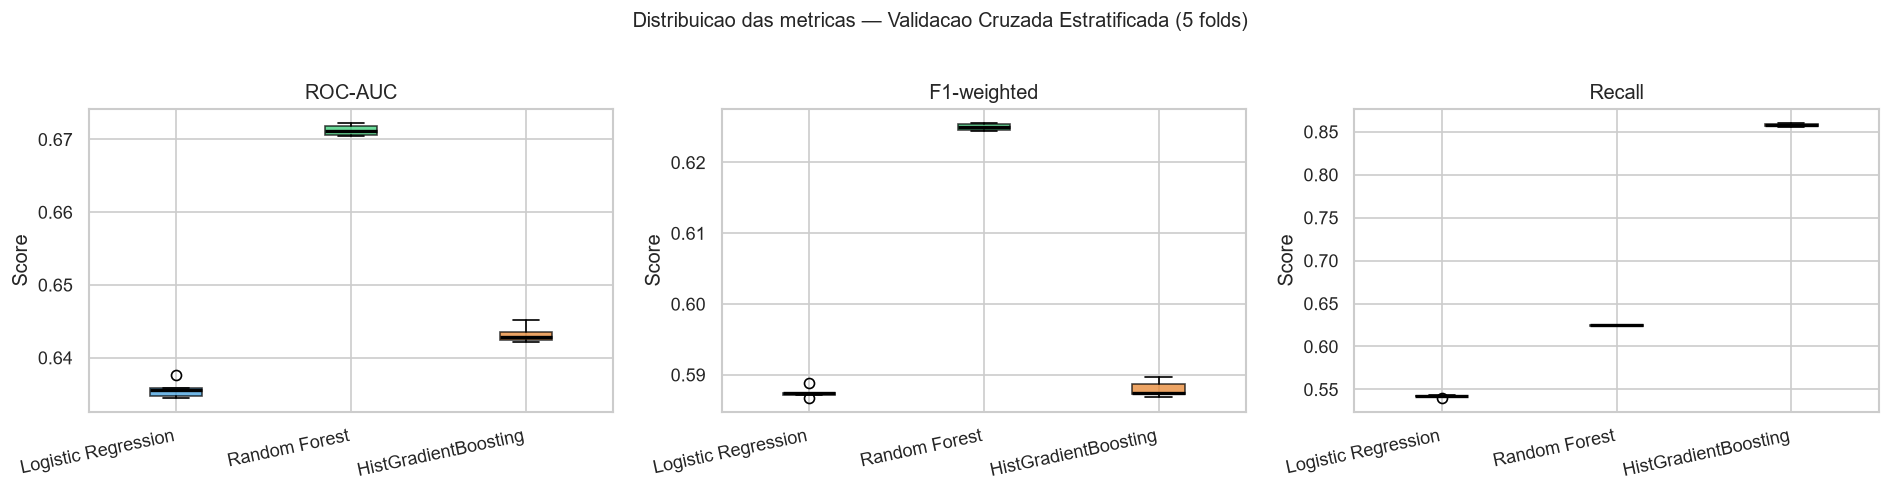

In [11]:
model_names = list(cv_results.keys())
metrics_keys = ['test_roc_auc', 'test_f1', 'test_recall']
metric_labels = ['ROC-AUC', 'F1-weighted', 'Recall']
colors = ['#3498db', '#2ecc71', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, label in zip(axes, metrics_keys, metric_labels):
    data = [cv_results[n][key] for n in model_names]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(model_names, rotation=12, ha='right')
    ax.set_title(label)
    ax.set_ylabel('Score')

plt.suptitle('Distribuicao das metricas — Validacao Cruzada Estratificada (5 folds)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Seleção do Modelo Final e Ajuste de Hiperparâmetros

> **Critério:** Melhor ROC-AUC na validação cruzada. Em empate técnico entre RF e HGBC, preferimos RF pela interpretabilidade mais direta no vídeo executivo.

In [ ]:
best_model_name = summary['ROC-AUC mean'].idxmax()
print(f'Modelo selecionado para tuning: {best_model_name}')

param_grids = {
    'Logistic Regression': {
        'clf__C':      [0.01, 0.1, 1.0, 10.0],
        'clf__solver': ['lbfgs', 'liblinear'],
    },
    'Random Forest': {
        'clf__n_estimators':   [100, 200, 300],
        'clf__max_depth':      [None, 10, 20],
        'clf__min_samples_leaf': [1, 5, 10],
    },
    'HistGradientBoosting': {
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth':     [4, 6, 8],
        'clf__max_iter':      [200, 300, 500],
    },
}

grid_search = GridSearchCV(
    estimator=models[best_model_name],
    param_grid=param_grids[best_model_name],
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

print('Executando GridSearchCV...')
grid_search.fit(X_train, y_train)

print(f'\nMelhores hiperparametros: {grid_search.best_params_}')
print(f'Melhor ROC-AUC (CV):      {grid_search.best_score_:.4f}')

final_model = grid_search.best_estimator_

Modelo selecionado para tuning: Random Forest
Executando GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


KeyboardInterrupt: 

: 

---
## 8. Avaliação Final no Conjunto de Teste

O test set é usado **uma única vez**, ao final, para estimativa não-enviesada da performance real.

In [ ]:
y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_pred_proba)
f1_test  = f1_score(y_test, y_pred, average='weighted')
rec_test = recall_score(y_test, y_pred)

print(f'ROC-AUC (test): {auc_test:.4f}')
print(f'F1 weighted:    {f1_test:.4f}')
print(f'Recall:         {rec_test:.4f}')

print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Nao Alfabetizado (0)', 'Alfabetizado (1)']
))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Nao Alfab.', 'Alfab.'],
    colorbar=False, ax=axes[0], cmap='Blues',
)
axes[0].set_title('Matriz de Confusao — Test Set')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2,
             label=f'{best_model_name} (AUC = {auc_test:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Curvas ROC de todos os modelos no test set
fig, ax = plt.subplots(figsize=(9, 6))

for (name, pipe), color in zip(models.items(), colors):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr_, tpr_, _ = roc_curve(y_test, proba)
    auc_ = roc_auc_score(y_test, proba)
    ax.plot(fpr_, tpr_, color=color, linewidth=2,
            label=f'{name} (AUC={auc_:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Comparacao de modelos (test set)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Feature Importance

In [ ]:
final_model.fit(X_train, y_train)

pre_step = final_model.named_steps['pre']
clf_step = final_model.named_steps['clf']

ohe_feature_names = []
if cat_features:
    ohe = pre_step.named_transformers_['cat'].named_steps['ohe']
    ohe_feature_names = list(ohe.get_feature_names_out(cat_features))

all_feature_names = num_features + ohe_feature_names
print(f'Total de features pos-OHE: {len(all_feature_names)}')

In [ ]:
if hasattr(clf_step, 'feature_importances_'):
    fi_df = (
        pd.DataFrame({'feature': all_feature_names,
                      'importance': clf_step.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(25)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color='#3498db', edgecolor='white')
    ax.set_title('Top 25 features por importancia — Modelo final')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()

    display(fi_df)

elif hasattr(clf_step, 'coef_'):
    fi_df = (
        pd.DataFrame({'feature': all_feature_names, 'coef': clf_step.coef_[0]})
        .assign(abs_coef=lambda x: x['coef'].abs())
        .sort_values('abs_coef', ascending=False)
        .head(25)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in fi_df['coef'][::-1]]
    ax.barh(fi_df['feature'][::-1], fi_df['coef'][::-1],
            color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 25 coeficientes — Regressao Logistica')
    ax.set_xlabel('Coeficiente (log-odds)')
    plt.tight_layout()
    plt.show()

    display(fi_df.drop(columns='abs_coef'))

---
## 10. SHAP Values — Interpretabilidade Global e Local

SHAP (SHapley Additive exPlanations) quantifica a contribuicao de cada feature para cada predicao individual, com garantia de consistencia matematica.

In [ ]:
try:
    import shap
    shap_available = True
    print('SHAP disponivel.')
except ImportError:
    shap_available = False
    print('shap nao instalado. Execute: pip install shap')

In [ ]:
if shap_available:
    X_test_transformed = pre_step.transform(X_test)
    X_test_trans_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

    n_shap = min(500, len(X_test_trans_df))
    X_shap_sample = X_test_trans_df.sample(n=n_shap, random_state=SEED)

    if hasattr(clf_step, 'feature_importances_'):
        explainer = shap.TreeExplainer(clf_step)
    else:
        explainer = shap.LinearExplainer(clf_step, X_shap_sample)

    shap_values = explainer(X_shap_sample)

    plt.figure(figsize=(11, 7))
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title('SHAP Beeswarm — Impacto global das features')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, max_display=20, show=False)
    plt.title('SHAP Bar — Importancia media das features')
    plt.tight_layout()
    plt.show()

In [ ]:
if shap_available:
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title('SHAP Waterfall — Explicacao individual (primeiro exemplo do test set)')
    plt.tight_layout()
    plt.show()

---
## 11. Perguntas de Negócio

### 11.1 Quais fatores mais impactam a alfabetização?

A EDA revelou dois achados centrais:
- **Proficiência** tem correlação quase perfeita (≈ 0,93) com a taxa de alfabetização — excluída por leakage, mas confirma que o modelo precisa de proxies que capturem a qualidade do ensino *antes* da prova.
- **Localização geográfica** é o segundo fator mais forte: CE lidera (taxa ponderada 8,50), enquanto SE e BA ficam em último (3,44 e 3,67 na escala 0–10). No modelo, `sigla_uf` e `regiao` carregam esse sinal.
- **Rede de ensino**: PRIVADA > ESTADUAL > MUNICIPAL (confirmado na EDA com teste t altamente significativo, p ≈ 0).

In [ ]:
if 'fi_df' in dir() and not fi_df.empty:
    imp_col = 'importance' if 'importance' in fi_df.columns else 'coef'
    print('TOP 5 fatores com maior impacto na predicao de alfabetizacao:')
    for i, row in fi_df.head(5).iterrows():
        print(f'  {i+1}. {row["feature"]:45s} => {row[imp_col]:.4f}')

### 11.2 Quais municípios apresentam maior risco educacional?

O modelo prevê a probabilidade de não-alfabetização por aluno; agregando por `sk_municipio`, obtemos o risco médio previsto por município.

Municípios com `risco_medio_previsto` alto e `taxa_real_nao_alfab` alta são candidatos prioritários a programas de intervenção. A EDA identificou SE, BA e RN como os estados com maiores concentrações de municípios de nível 1 e 2 (risco máximo).

> **Nota:** a análise abaixo usa apenas o *test set* (20% dos dados). Para produção, o ideal é aplicar o modelo treinado sobre o conjunto completo.

In [ ]:
df_test_pred = X_test.copy().reset_index(drop=True)
df_test_pred['y_true']        = y_test.values
df_test_pred['y_pred']        = y_pred
df_test_pred['proba_alfabet'] = y_pred_proba
df_test_pred['proba_risco']   = 1 - y_pred_proba
df_test_pred['sk_municipio']  = df.loc[y_test.index, 'sk_municipio'].values

risco_mun_pred = (
    df_test_pred.groupby('sk_municipio')
    .agg(
        n_alunos=('y_true', 'count'),
        taxa_real_nao_alfab=('y_true', lambda x: (1 - x).mean()),
        risco_medio_previsto=('proba_risco', 'mean'),
    )
    .query('n_alunos >= 10')
    .sort_values('risco_medio_previsto', ascending=False)
    .head(20)
)

print('Top 20 municipios com maior risco educacional previsto:')
display(risco_mun_pred.round(3))

### 11.3 Calibração do modelo — as probabilidades são confiáveis?

Um modelo bem calibrado emite probabilidades alinhadas à frequência real de eventos.  
Isso é crítico para rankear municípios por risco: se o modelo diz 70% de chance de não-alfabetização,  
~70% dos alunos nessa faixa devem de fato não estar alfabetizados.

A curva de calibração abaixo compara a probabilidade média prevista com a fração real de positivos.

In [ ]:
fop, mpv = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Calibracao perfeita')
ax.plot(mpv, fop, marker='o', color='#2ecc71', linewidth=2, label='Modelo final')
ax.set_xlabel('Probabilidade media prevista')
ax.set_ylabel('Fracao de positivos reais')
ax.set_title('Calibration Plot — Confiabilidade das probabilidades')
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Resumo e Conclusões

### Contexto dos dados (da EDA)
- **Base:** 3.354.661 alunos, série 2, ano 2024 — todos com presença confirmada e caderno preenchido
- **Taxa de alfabetização:** 59,16% (desbalanceamento moderado → `class_weight='balanced'` justificado)
- **Rede predominante:** MUNICIPAL (88,9% dos alunos), ESTADUAL (11,1%), PRIVADA (<0,01%)
- **Disparidade regional:** CE (taxa ponderada 8,50) ↔ SE (3,44) — diferença de 5+ pontos na escala 0–10
- **Nulos:** `fato_desempenho` não tem nulos; `fato_alfabetizacao` tem 4.799 nulos em `meta_alfabetizacao_projetada` e `desvio_da_meta` (irrelevante — tabela excluída do modelo)

### Comparativo de modelos

In [ ]:
print('=== Resumo da Validacao Cruzada (5 folds, treino) ===')
display(summary.sort_values('ROC-AUC mean', ascending=False))

print(f'\n=== Modelo selecionado: {best_model_name} ===')
print(f'ROC-AUC (test): {auc_test:.4f}')
print(f'F1 (test):      {f1_test:.4f}')
print(f'Recall (test):  {rec_test:.4f}')

### Decisões tomadas e justificativas

| Decisão | Justificativa |
|---|---|
| Excluir `proficiencia` | Leakage direto — o corte de pontuação define `alfabetizado` (EDA: separação visual quase perfeita) |
| Excluir `fato_alfabetizacao_consolidada` | Leakage por agrupamento (EDA: corr ≈ 0,93); join sem `rede`+`ano` também criaria linhas duplicadas |
| Excluir `ano`, `serie`, `presenca`, `preenchimento_caderno` | Variância zero confirmada na EDA (valor único na base 2024) |
| Excluir `id_escola`, `id_municipio`, `id_uf` | Identificadores de alta cardinalidade sem poder preditivo generalizável |
| Incluir `sigla_uf` e `regiao` | EDA mostrou efeito regional fortíssimo: CE (8,5) vs SE (3,4) na escala 0–10 |
| StratifiedKFold | Preserva proporção das classes (~59% alfab / ~41% não-alfab) em cada fold |
| `class_weight='balanced'` | Penaliza erros na classe minoritária; custo assimétrico: falso negativo tem maior impacto social |
| Imputer dentro do Pipeline | Evita data leakage do pré-processamento nos folds de CV |
| Métricas: AUC + F1 + Recall | Acurácia isolada é enganosa com desbalanceamento de classes |
| SHAP TreeExplainer | Rápido para florestas/boosting e matematicamente consistente (Shapley values) |

### Próximos passos

1. **Threshold tuning** — ajustar o ponto de corte de probabilidade para maximizar recall de não-alfabetizados (um falso negativo — aluno não-alfabetizado classificado como alfabetizado — tem custo social maior que um falso positivo)
2. **Análise de cluster de municípios** — K-Means sobre `fato_alfabetizacao_consolidada` para agrupar municípios por perfil de alfabetização (uso legítimo da tabela sem cruzar com `fato_desempenho`)
3. **Enriquecimento externo** — IBGE (PIB per capita, IDH municipal), FUNDEB (investimento por aluno), dados de infraestrutura (internet, transporte escolar)
4. **Modelagem temporal** — com dados de múltiplos anos, prever municípios que não atingirão as metas futuras (CE lidera hoje mas a evolução temporal é desconhecida)
5. **Análise de erros por UF** — inspecionar onde o modelo erra mais; estados com alta heterogeneidade interna (SP, MG, BA) costumam ter maior taxa de erro e merecem atenção especial
6. **Feature engineering avançado** — criar features de interação `rede × regiao` e variáveis de contexto escolar a partir do `id_escola` (e.g., tamanho médio da escola por município)

In [ ]:
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/modelo_final.joblib')
print('Modelo salvo em ../models/modelo_final.joblib')